In [2]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import make_image_grid, load_image
from PIL import Image

sd1_path = "stable-diffusion-v1-5"

# Load the pretrained SD 1.5 img2img pipeline
pipeline = AutoPipelineForImage2Image.from_pretrained(
    sd1_path,  # Use correct model repo
    torch_dtype=torch.float16,
    variant="fp16",
    safety_checker=None,
    use_safetensors=True,
).to("cuda")


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/5 [00:00<?, ?it/s]

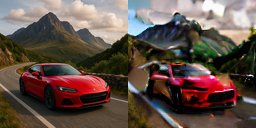

In [9]:
# Load input image
image_path = r"target_images/a red sports car on a mountain road.png"
init_image = Image.open(image_path).convert("RGB")

# Define prompt
prompt = "a color icon of a red sports car on a mountain road"

# Generate image
result = pipeline(prompt=prompt, image=init_image, strength=0.1, guidance_scale=7.5).images[0]

# Display comparison grid
make_image_grid([init_image, result], rows=1, cols=2)